# PSD & theta from CA1 recordings


## Load LFP and packages

In [40]:
import os
import numpy as np
from pathlib import Path
from scipy import signal
from fooof import FOOOF
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
base_dir = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP")

# recording (for TTL + timestamps)
rec_folder  = base_dir / "2025-07-30_16-22-55-AM/Record Node 101/experiment1/recording14"
ttl_folder  = rec_folder / "events/Acquisition_Board-102.Rhythm Data/TTL"
cont_folder = rec_folder / "continuous/Acquisition_Board-102.Rhythm Data"

# downsampled LFP
ds_path = base_dir / "downsample/RawDataChannelExtractedDS.npy"
assert ds_path.is_file(), f"Downsampled LFP not found: {ds_path}"

# ============================================================
# Sampling rates
# ============================================================
fs_raw = 2000.0
fs_ds  = 1000.0
ratio  = int(fs_raw / fs_ds)
assert fs_raw % fs_ds == 0, "fs_raw must be integer multiple of fs_ds"

# ============================================================
# Load downsampled LFP
# ============================================================
lfp_ds = np.load(ds_path, mmap_mode="r")   # (time, channels)
n_ds   = lfp_ds.shape[0]

print("Loaded LFP:", lfp_ds.shape, "fs =", fs_ds)

# ============================================================
# Load TTL and convert to DS indices
# ============================================================
stim_samp = np.load(ttl_folder / "sample_numbers.npy")
states    = np.load(ttl_folder / "states.npy")

# anchor: first continuous sample number
cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

def extract_ttl1(sample_numbers, states):
    """Return Nx2 array of [start, end] sample numbers (RAW grid)."""
    start_idx = np.where(states == 1)[0]
    end_idx   = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    pulses = np.stack(
        [sample_numbers[start_idx[:n]],
         sample_numbers[end_idx[:n]]],
        axis=1
    )
    return pulses[pulses[:, 1] > pulses[:, 0]]

# TTL in raw sample numbers
pulses_raw = extract_ttl1(stim_samp, states)

# convert → raw indices relative to LFP start
pulses_idx = (pulses_raw - cont0).astype(np.int64)

# convert → downsampled indices
pulses_ds = pulses_idx // ratio

# safety clipping
pulses_ds[:, 0] = np.clip(pulses_ds[:, 0], 0, n_ds - 1)
pulses_ds[:, 1] = np.clip(pulses_ds[:, 1], 0, n_ds - 1)
pulses_ds = pulses_ds[pulses_ds[:, 1] > pulses_ds[:, 0]]

print("TTL1 pulses (DS):", pulses_ds.shape)

Loaded LFP: (195968, 32) fs = 1000.0
TTL1 pulses (DS): (651, 2)


In [18]:
# ============================================================
# TTL timing table
# ============================================================
import pandas as pd

# Use pulse start/end in downsampled index space
ttl_start_s = pulses_ds[:, 0] / fs_ds
ttl_end_s   = pulses_ds[:, 1] / fs_ds
ttl_dur_s   = ttl_end_s - ttl_start_s
ttl_delta_s = np.r_[np.nan, np.diff(ttl_start_s)]  # inter-pulse interval (start-to-start)

ttl_table = pd.DataFrame({
    'pulse_idx': np.arange(len(pulses_ds)),
    'start_s': ttl_start_s,
    'end_s': ttl_end_s,
    'duration_s': ttl_dur_s,
    'delta_from_prev_s': ttl_delta_s,
})

display(ttl_table)
print('TTL pulses:', len(ttl_table))


,pulse_idx,start_s,end_s,duration_s,delta_from_prev_s
0,0,12.579,12.583,0.004,NaN
1,1,12.628,12.634,0.006,0.049
2,2,12.679,12.685,0.006,0.051
3,3,12.730,12.736,0.006,0.051
4,4,12.781,12.788,0.007,0.051
...,...,...,...,...,...
646,646,193.914,193.920,0.006,0.856
647,647,193.966,193.972,0.006,0.052
648,648,194.017,194.023,0.006,0.051
649,649,194.068,194.074,0.006,0.051


TTL pulses: 651


In [19]:

def bandpass_150_250(x, fs, order=4):
    """Stable zero-phase bandpass using SOS."""
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    sos = signal.butter(order, [150/nyq, 250/nyq], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, x)

def contiguous_segments(mask):
    """Return list of (start, end) index pairs for True segments in a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    edges = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0]
    return list(zip(starts, ends))

def events_from_mask(mask, fs, min_dur_ms=15, envelope=None):
    """
    Convert threshold mask into events with start/end/peak.
    envelope: optional array for peak finding (defaults to None).
    """
    min_len = int(round(fs * min_dur_ms / 1000.0))
    ev = []
    for s, e in contiguous_segments(mask):
        if (e - s) < min_len:
            continue
        if envelope is None:
            peak = (s + e) // 2
            pkval = np.nan
        else:
            peak = s + int(np.argmax(envelope[s:e]))
            pkval = float(envelope[peak])
        ev.append(dict(start=s, end=e, peak=peak, peak_value=pkval,
                       start_s=s/fs, end_s=e/fs, peak_s=peak/fs,
                       duration_ms=(e - s) * 1000.0 / fs))
    return ev

 #  #  # Define stim mask

In [20]:
import numpy as np
import pandas as pd

def build_stim_mask_from_trains(
    n_samples: int,
    pulses_ds: np.ndarray,
    fs: float,
    gap_s: float = 1.0,          # train boundary if next start - current start > gap_s
    pre_s: float = 0.0,          # optional: expand each train earlier
    post_s: float = 0.0,         # optional: expand each train later
):
    """
    Define STIM-ON as TTL trains:
      - train starts at start of first TTL pulse
      - train ends at end of last TTL pulse before a start-to-start gap > gap_s
    Returns:
      stim_mask (bool, length n_samples)
      trains_ds (Nx2 int): [train_start_idx, train_end_idx] in DS sample indices
      trains_table (pd.DataFrame): train start/end in seconds + duration
    """
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    # sort by start (safety)
    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends   = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end   = int(ends[0])

    for i in range(1, len(pulses)):
        # boundary rule based on start-to-start gap
        if (int(starts[i]) - int(starts[i-1])) > gap:
            # close current train
            trains.append((cur_start, cur_end))
            # start new train
            cur_start = int(starts[i])
            cur_end   = int(ends[i])
        else:
            # still same train
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))  # last train

    # Apply optional expansion + build mask
    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds)),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table


# ----------------------------
# Example usage
# ----------------------------
fs = fs_ds
n  = lfp_ds.shape[0]

stim_mask, stim_trains_ds, stim_trains_table = build_stim_mask_from_trains(
    n_samples=n,
    pulses_ds=pulses_ds,
    fs=fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0
)

nostim_mask = ~stim_mask

display(stim_trains_table)
print("n pulses:", len(pulses_ds))
print("n stim trains:", len(stim_trains_ds))
print("stim samples:", stim_mask.sum(), "(", stim_mask.sum()/fs, "s )")
print("no-stim samples:", nostim_mask.sum(), "(", nostim_mask.sum()/fs, "s )")

,train_idx,start_s,end_s,duration_s
0,0,12.579,17.049,4.470
1,1,24.331,26.662,2.331
2,2,36.591,45.315,8.724
3,3,47.767,54.398,6.631
4,4,56.856,64.538,7.682
5,5,69.638,77.295,7.657
6,6,91.506,93.864,2.358
7,7,98.456,100.788,2.332
8,8,102.707,170.116,67.409
9,9,173.659,194.125,20.466


n pulses: 651
n stim trains: 10
stim samples: 130060 ( 130.06 s )
no-stim samples: 65908 ( 65.908 s )


In [27]:
# ----------------------------
# Pre-stim window (10 s before first train)
# ----------------------------
pre_stim_mask = np.zeros(n, dtype=bool)
pre_stim_window_s = 10.0

if stim_trains_ds is not None and len(stim_trains_ds) > 0:
    first_start = int(stim_trains_ds[0, 0])
    pre_len = int(round(pre_stim_window_s * fs))
    s0 = max(0, first_start - pre_len)
    e0 = max(0, first_start)
    if e0 > s0:
        pre_stim_mask[s0:e0] = True

pre_stim_seconds = pre_stim_mask.sum() / fs
print("pre-stim seconds:", pre_stim_seconds)
print("first_start / fs", first_start / fs)


pre-stim seconds: 10.0
first_start / fs 12.579


/Users/stella/miniforge3/envs/cheeseboard-lfp/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


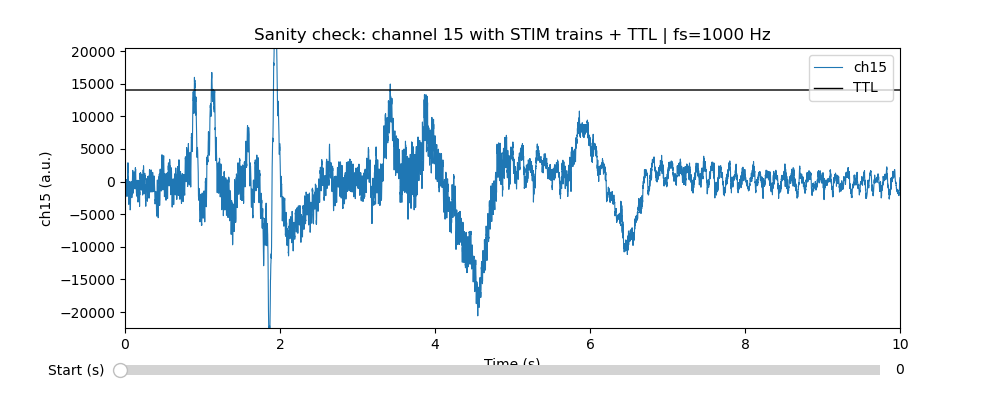

In [21]:
# ============================================================
# Sanity plot: LFP + shaded trains + TTL trace overlay
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def sanity_plot_trains_on_trace(
    lfp_ds, fs, trains_ds,
    ch=0,
    start_s=0.0, window_s=10.0,
    y_mode="percentile",   # "percentile" or "fixed"
    y_fixed=2000.0,
    train_alpha=0.18,
    ttl_trace=None,          # 1D array in DS samples (same length as lfp_ds)
    ttl_pulses_ds=None,      # optional Nx2 [start,end] to synthesize TTL trace
    ttl_height=0.15,         # fraction of axis height used for TTL display
    ttl_color="k"
):
    """
    Plot ONE channel trace with STIM-ON trains shaded.
      lfp_ds: (time, ch)
      trains_ds: Nx2 int [start_idx, end_idx] in DS sample indices
      ttl_trace: optional 1D array to overlay (e.g., raw TTL channel)
      ttl_pulses_ds: optional pulses to build a binary TTL trace
    """
    x = np.asarray(lfp_ds[:, ch], dtype=np.float32)
    n = x.size
    trains_ds = np.asarray(trains_ds, dtype=np.int64) if trains_ds is not None else np.zeros((0, 2), dtype=np.int64)

    # build TTL trace if needed
    if ttl_trace is None and ttl_pulses_ds is not None:
        ttl_trace = np.zeros(n, dtype=np.float32)
        for s_idx, e_idx in np.asarray(ttl_pulses_ds, dtype=np.int64):
            s0 = max(0, int(s_idx))
            e0 = min(n, int(e_idx))
            if e0 > s0:
                ttl_trace[s0:e0] = 1.0

    fig, ax = plt.subplots(figsize=(10, 4))
    plt.subplots_adjust(bottom=0.18)

    ax_sl = fig.add_axes([0.12, 0.05, 0.76, 0.05])
    max_start = max(0.0, (n / fs) - window_s)
    fig._slider = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)
    sld = fig._slider

    def set_ylim(seg):
        if y_mode == "fixed":
            ax.set_ylim(-y_fixed, y_fixed)
        else:
            lo, hi = np.percentile(seg, [1, 99])
            pad = 0.25 * (hi - lo + 1e-9)
            ax.set_ylim(lo - pad, hi + pad)

    def render(s0):
        ax.clear()
        i0 = int(s0 * fs)
        i1 = min(int((s0 + window_s) * fs), n)

        t = np.arange(i0, i1) / fs
        seg = x[i0:i1]

        ax.plot(t, seg, lw=0.8, label=f"ch{ch}")

        # shade trains that overlap this window
        if trains_ds.size:
            mask = (trains_ds[:, 1] > i0) & (trains_ds[:, 0] < i1)
            first = True
            for s_idx, e_idx in trains_ds[mask]:
                s = max(int(s_idx), i0) / fs
                e = min(int(e_idx), i1) / fs
                ax.axvspan(s, e, alpha=train_alpha, label="STIM train" if first else None)
                first = False

        ax.set_xlim(s0, s0 + window_s)
        set_ylim(seg)

        # overlay TTL trace near the top of the axis
        if ttl_trace is not None:
            ttl_seg = np.asarray(ttl_trace[i0:i1], dtype=np.float32)
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * float(ttl_height)
            base = y1 - h
            y = base + ttl_seg * h
            ax.plot(t, y, color=ttl_color, lw=1.0, label="TTL")

        ax.set_xlabel("Time (s)")
        ax.set_ylabel(f"ch{ch} (a.u.)")
        ax.set_title(f"Sanity check: channel {ch} with STIM trains + TTL | fs={fs:.0f} Hz")
        ax.grid(False)

        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc="upper right")

        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()

# ---- Run it ----
# Option A: if you already have a TTL trace array (same length as lfp_ds), pass it as ttl_trace.
# Option B: build TTL from pulses_ds via ttl_pulses_ds.
sanity_plot_trains_on_trace(
    lfp_ds=lfp_ds,
    fs=fs_ds,
    trains_ds=stim_trains_ds,
    ch=15,
    start_s=0.0,
    window_s=10.0,
    y_mode="percentile",
    ttl_pulses_ds=pulses_ds,   # or ttl_trace=TTL
)


compute the difference between two traces (from same site)

In [ ]:
def bipolar(lfp, ch1, ch2):
    return np.asarray(lfp[:, ch1] - lfp[:, ch2], dtype=np.float32)

Welch PSD (0.5 s window, 0.25 s overlap), 1–200 Hz

In [39]:
from scipy import signal

def contiguous_true_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    d = np.diff(mask.astype(np.int8))
    starts = np.where(d == 1)[0] + 1
    ends   = np.where(d == -1)[0] + 1
    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size]
    return list(zip(starts, ends))

def welch_psd_from_mask(x, fs, mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200):
    x = np.asarray(x, dtype=np.float32)
    nperseg  = int(round(win_s * fs))
    noverlap = int(round(overlap_s * fs))
    assert nperseg > 0 and 0 <= noverlap < nperseg

    segs = contiguous_true_segments(mask)
    psds = []
    f_ref = None

    for s, e in segs:
        if (e - s) < nperseg:
            continue
        f, Pxx = signal.welch(x[s:e], fs=fs, nperseg=nperseg, noverlap=noverlap)
        if f_ref is None:
            f_ref = f
        psds.append(Pxx)

    if len(psds) == 0:
        raise ValueError("No usable data for Welch PSD (mask too strict or recording too short).")

    Pxx_mean = np.mean(np.vstack(psds), axis=0)
    sel = (f_ref >= fmin) & (f_ref <= fmax)
    return f_ref[sel], Pxx_mean[sel]

Compute PSD for STIM and NO_STIM (RIGHT + LEFT)

STIM seconds: 130.06
NO_STIM seconds: 65.908
PRE_STIM seconds: 10.0


/Users/stella/miniforge3/envs/cheeseboard-lfp/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


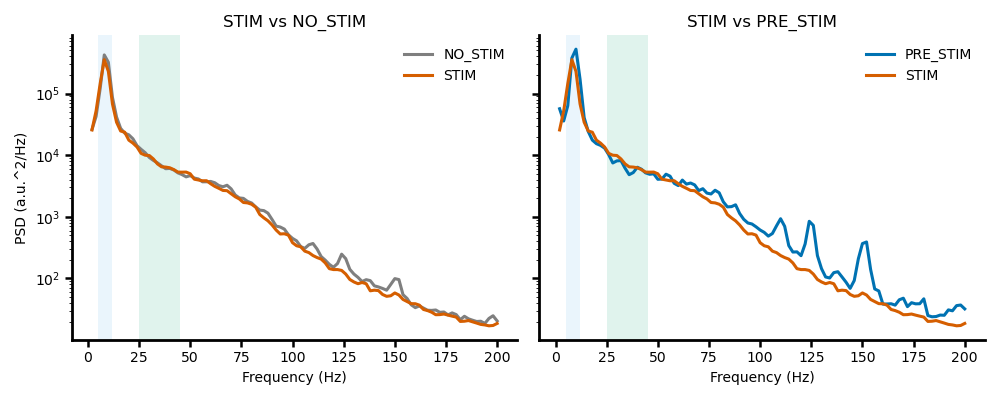

In [49]:
# --- REQUIRED: lfp_ds, fs_ds, stim_mask, nostim_mask, pre_stim_mask already defined ---
fs = float(fs_ds)

print("STIM seconds:", stim_mask.sum() / fs)
print("NO_STIM seconds:", nostim_mask.sum() / fs)
print("PRE_STIM seconds:", pre_stim_mask.sum() / fs)

pairs = {"RIGHT": (9, 15), "LEFT": (25, 27)}

psd = {}  # psd[hemi][cond] = (f, Pxx)

for hemi, (c1, c2) in pairs.items():
    x = (lfp_ds[:, c1] - lfp_ds[:, c2]).astype(np.float32)

    f, P_stim = welch_psd_from_mask(x, fs, stim_mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200)
    _, P_nostim = welch_psd_from_mask(x, fs, nostim_mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200)
    _, P_prestim  = welch_psd_from_mask(x, fs, pre_stim_mask, win_s=0.5, overlap_s=0.25, fmin=1, fmax=200)

    psd[hemi] = {
        "STIM": (f, P_stim),
        "NO_STIM": (f, P_nostim),
        "PRE_STIM": (f, P_prestim),
    }

# ---- Mean PSD across hemispheres ----
f = psd["RIGHT"]["STIM"][0]
P_stim_mean = np.mean([psd[h]["STIM"][1] for h in psd], axis=0)
P_nostim_mean = np.mean([psd[h]["NO_STIM"][1] for h in psd], axis=0)
P_prestim_mean = np.mean([psd[h]["PRE_STIM"][1] for h in psd], axis=0)

theta_band = (5, 12)
gamma_band = (25, 45)

nostim_color = "#7f7f7f"
prestim_color = "#0072B2"  # blue
stim_color = "#D55E00"     # red/orange

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

comparisons = [
    ("NO_STIM", P_nostim_mean, "STIM vs NO_STIM", nostim_color),
    ("PRE_STIM", P_prestim_mean, "STIM vs PRE_STIM", prestim_color),
]

for ax, (off_label, P_off, title, off_color) in zip(axes, comparisons):
    # background bands
    ax.axvspan(theta_band[0], theta_band[1], color="#56B4E9", alpha=0.12, lw=0)
    ax.axvspan(gamma_band[0], gamma_band[1], color="#009E73", alpha=0.12, lw=0)

    ax.semilogy(f, P_off, color=off_color, lw=2.2, label=off_label)
    ax.semilogy(f, P_stim_mean, color=stim_color, lw=2.2, label="STIM")

    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.grid(False)
    ax.legend(frameon=False)

    # publication-style axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(width=1.8, length=5)

axes[0].set_ylabel("PSD (a.u.^2/Hz)")
plt.tight_layout()
plt.show()

/Users/stella/miniforge3/envs/cheeseboard-lfp/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


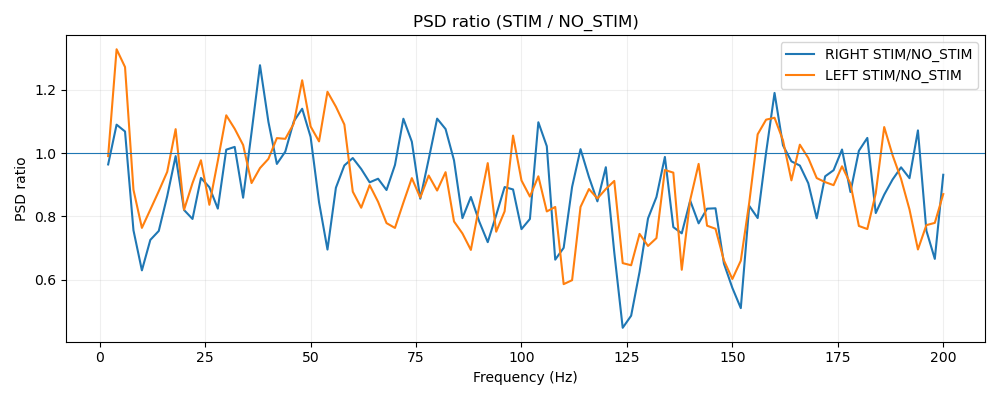

In [42]:
plt.figure(figsize=(10, 4))

for hemi in ["RIGHT", "LEFT"]:
    f, P_stim = psd[hemi]["STIM"]
    _, P_base = psd[hemi]["NO_STIM"]
    ratio = P_stim / (P_base + 1e-20)
    plt.plot(f, ratio, label=f"{hemi} STIM/NO_STIM")

plt.axhline(1.0, lw=0.8)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD ratio")
plt.title("PSD ratio (STIM / NO_STIM)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

compute theta. 
FOOOF fitting in two ranges (3–15 and 15–150), then grab theta peak (5–12)

Typical settings for hippocampus:
	•	Frequency range: 3–150 Hz
	•	Peak width limits: ~ 1–12 Hz
	•	Max peaks: 6–8
	•	Aperiodic mode: "fixed"
	•	Separate fits:
	•	3–15 Hz (theta)
	•	15–150 Hz (gamma)

In [43]:
def fit_fooof_two_ranges(freqs, psd, peak_width_limits=(1, 12), max_n_peaks=6, min_peak_height=0.1):
    """
    Fit FOOOF separately in:
      - low: 3–15 Hz (theta)
      - high: 15–150 Hz (gamma and higher)
    Return both models.
    """
    fm_low = FOOOF(
        peak_width_limits=peak_width_limits,
        max_n_peaks=max_n_peaks,
        min_peak_height=min_peak_height,
        aperiodic_mode="fixed",
        verbose=False
    )
    fm_high = FOOOF(
        peak_width_limits=peak_width_limits,
        max_n_peaks=max_n_peaks,
        min_peak_height=min_peak_height,
        aperiodic_mode="fixed",
        verbose=False
    )

    fm_low.fit(freqs, psd, freq_range=[3, 15])
    fm_high.fit(freqs, psd, freq_range=[15, 150])

    return fm_low, fm_high


def _pick_strongest_peak_in_band(fm, band):
    """
    Helper: pick strongest FOOOF peak (largest PW) within a frequency band.
    Returns dict with cf/pw/bw, or None if no peak found.
    """
    peaks = fm.get_params('peak_params')  # array: [CF, PW, BW]
    if peaks is None or len(peaks) == 0:
        return None

    peaks = np.asarray(peaks)
    in_band = (peaks[:, 0] >= band[0]) & (peaks[:, 0] <= band[1])
    cand = peaks[in_band]
    if cand.size == 0:
        return None

    best = cand[np.argmax(cand[:, 1])]
    return {"cf": float(best[0]), "pw": float(best[1]), "bw": float(best[2])}


def extract_theta_from_low_model(fm_low, theta_band=(5, 12)):
    """
    From the LOW-range FOOOF model, pick strongest peak in theta band.
    Returns dict with theta_cf/theta_pw/theta_bw, or None.
    """
    best = _pick_strongest_peak_in_band(fm_low, theta_band)
    if best is None:
        return None
    return {"theta_cf": best["cf"], "theta_pw": best["pw"], "theta_bw": best["bw"]}


def extract_gamma_from_high_model(fm_high, gamma_band=(25, 45)):
    """
    From the HIGH-range FOOOF model, pick strongest peak in slow gamma band.
    Returns dict with gamma_cf/gamma_pw/gamma_bw, or None.
    """
    best = _pick_strongest_peak_in_band(fm_high, gamma_band)
    if best is None:
        return None
    return {"gamma_cf": best["cf"], "gamma_pw": best["pw"], "gamma_bw": best["bw"]}


def get_aperiodic_params(fm):
    ap = fm.get_params('aperiodic_params')
    # fixed mode: [offset, exponent]
    return {"offset": float(ap[0]), "exponent": float(ap[1])}

In [44]:
# Bipolar channel pairs
channel_pairs = {
    "RIGHT": (9, 15),
    "LEFT":  (25, 27),
}

results = {}

for hemi, (ch_a, ch_b) in channel_pairs.items():

    # ------------------------
    # Bipolar LFP
    # ------------------------
    lfp_bipolar = bipolar(lfp_ds, ch_a, ch_b)

    # ------------------------
    # PSD (Welch)
    # ------------------------
    freqs, psd_stim = welch_psd_from_mask(
        lfp_bipolar, fs, stim_mask,
        win_s=0.5, overlap_s=0.25,
        fmin=1, fmax=200
    )

    _, psd_nostim = welch_psd_from_mask(
        lfp_bipolar, fs, nostim_mask,
        win_s=0.5, overlap_s=0.25,
        fmin=1, fmax=200
    )

    _, psd_prestim = welch_psd_from_mask(
        lfp_bipolar, fs, pre_stim_mask,
        win_s=0.5, overlap_s=0.25,
        fmin=1, fmax=200
    )

    # ------------------------
    # FOOOF fits (low/high ranges)
    # ------------------------
    fooof_low_stim, fooof_high_stim = fit_fooof_two_ranges(freqs, psd_stim)
    fooof_low_nostim, fooof_high_nostim = fit_fooof_two_ranges(freqs, psd_nostim)
    fooof_low_prestim, fooof_high_prestim = fit_fooof_two_ranges(freqs, psd_prestim)

    # ------------------------
    # Theta metrics (5–12 Hz)
    # ------------------------
    theta_stim = extract_theta_from_low_model(
        fooof_low_stim, theta_band=(5, 12)
    )

    theta_nostim = extract_theta_from_low_model(
        fooof_low_nostim, theta_band=(5, 12)
    )

    theta_prestim = extract_theta_from_low_model(
        fooof_low_prestim, theta_band=(5, 12)
    )

    # ------------------------
    # Gamma metrics (25–45 Hz)
    # ------------------------
    gamma_stim = extract_gamma_from_high_model(
        fooof_high_stim, gamma_band=(25, 45)
    )

    gamma_nostim = extract_gamma_from_high_model(
        fooof_high_nostim, gamma_band=(25, 45)
    )

    gamma_prestim = extract_gamma_from_high_model(
        fooof_high_prestim, gamma_band=(25, 45)
    )

    # ------------------------
    # Store results
    # ------------------------
    results[hemi] = {
        "PSD": {
            "freqs": freqs,
            "STIM": psd_stim,
            "NO_STIM": psd_nostim,
            "PRE_STIM": psd_prestim,
        },
        "FOOOF_LOW": {
            "STIM": fooof_low_stim,
            "NO_STIM": fooof_low_nostim,
            "PRE_STIM": fooof_low_prestim,
        },
        "FOOOF_HIGH": {
            "STIM": fooof_high_stim,
            "NO_STIM": fooof_high_nostim,
            "PRE_STIM": fooof_high_prestim,
        },
        "THETA": {
            "STIM": theta_stim,
            "NO_STIM": theta_nostim,
            "PRE_STIM": theta_prestim,
        },
        "GAMMA": {
            "STIM": gamma_stim,
            "NO_STIM": gamma_nostim,
            "PRE_STIM": gamma_prestim,
        },
        "APERIODIC": {
            "STIM": get_aperiodic_params(fooof_low_stim),
            "NO_STIM": get_aperiodic_params(fooof_low_nostim),
            "PRE_STIM": get_aperiodic_params(fooof_low_prestim),
        },
    }

    stim_cf = np.nan if theta_stim is None else theta_stim["theta_cf"]
    nostim_cf = np.nan if theta_nostim is None else theta_nostim["theta_cf"]
    prestim_cf = np.nan if theta_prestim is None else theta_prestim["theta_cf"]

    print(
        f"{hemi} | Theta CF STIM={stim_cf:.2f} Hz, "
        f"NO_STIM={nostim_cf:.2f} Hz, PRE_STIM={prestim_cf:.2f} Hz"
    )

RIGHT | Theta CF STIM=8.43 Hz, NO_STIM=8.64 Hz, PRE_STIM=9.52 Hz
LEFT | Theta CF STIM=8.44 Hz, NO_STIM=8.61 Hz, PRE_STIM=9.49 Hz


Plot: PSD + aperiodic fits + theta peak markers (STIM vs NO-STIM)


/Users/stella/miniforge3/envs/cheeseboard-lfp/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


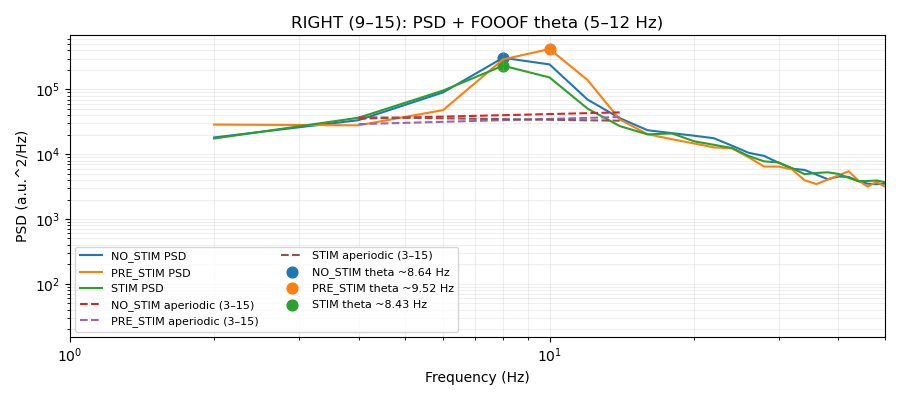

/Users/stella/miniforge3/envs/cheeseboard-lfp/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


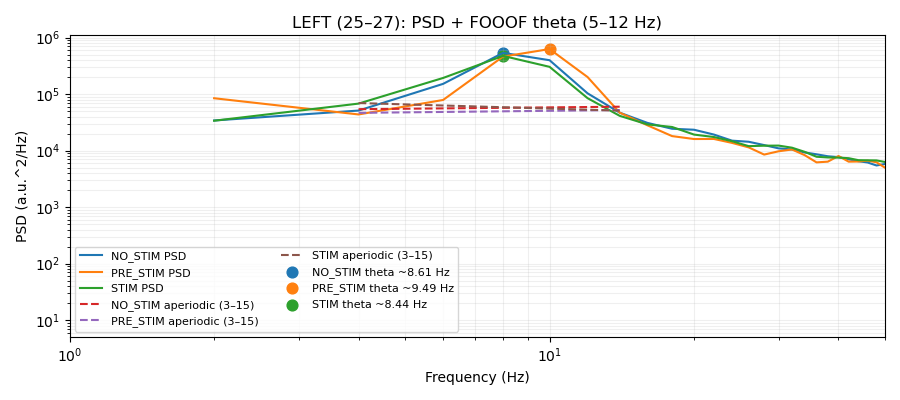

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def aperiodic_curve(freqs, offset, exponent):
    """
    FOOOF 'fixed' aperiodic in log10 power:
      log10(P) = offset - exponent * log10(f)
    so P = 10**offset * f**(-exponent)
    """
    freqs = np.asarray(freqs, dtype=float)
    return (10 ** offset) * (freqs ** (-exponent))

def plot_fooof_theta_comparison(res_hemi, hemi_label, xlim=(1, 50)):
    # ---- unpack from YOUR nested structure ----
    f = np.asarray(res_hemi["PSD"]["freqs"])
    P_stim = np.asarray(res_hemi["PSD"]["STIM"])
    P_nostim = np.asarray(res_hemi["PSD"]["NO_STIM"])
    P_prestim = np.asarray(res_hemi["PSD"]["PRE_STIM"])

    th_stim = res_hemi["THETA"]["STIM"]       # dict or None
    th_nostim = res_hemi["THETA"]["NO_STIM"]   # dict or None
    th_prestim = res_hemi["THETA"]["PRE_STIM"] # dict or None

    ap_stim = res_hemi["APERIODIC"]["STIM"]       # {"offset":..., "exponent":...}
    ap_nostim = res_hemi["APERIODIC"]["NO_STIM"]
    ap_prestim = res_hemi["APERIODIC"]["PRE_STIM"]

    fig, ax = plt.subplots(figsize=(9, 4))

    # PSD (log-log)
    ax.loglog(f, P_nostim, label="NO_STIM PSD")
    ax.loglog(f, P_prestim, label="PRE_STIM PSD")
    ax.loglog(f, P_stim, label="STIM PSD")

    # aperiodic curves (plot only in 3–15 Hz since that's what you fit in fm_low)
    low_sel = (f >= 3) & (f <= 15)
    f_low = f[low_sel]

    P_ap_nostim = aperiodic_curve(f_low, ap_nostim["offset"], ap_nostim["exponent"])
    P_ap_prestim = aperiodic_curve(f_low, ap_prestim["offset"], ap_prestim["exponent"])
    P_ap_stim = aperiodic_curve(f_low, ap_stim["offset"], ap_stim["exponent"])

    ax.loglog(f_low, P_ap_nostim, "--", label="NO_STIM aperiodic (3–15)")
    ax.loglog(f_low, P_ap_prestim, "--", label="PRE_STIM aperiodic (3–15)")
    ax.loglog(f_low, P_ap_stim, "--", label="STIM aperiodic (3–15)")

    # theta markers (theta_cf keys)
    for lab, th, y_psd in [
        ("NO_STIM", th_nostim, P_nostim),
        ("PRE_STIM", th_prestim, P_prestim),
        ("STIM", th_stim, P_stim),
    ]:
        if th is not None:
            cf = float(th["theta_cf"])
            idx = int(np.argmin(np.abs(f - cf)))
            ax.scatter([f[idx]], [y_psd[idx]], s=60, label=f"{lab} theta ~{cf:.2f} Hz")

    ax.set_xlim(*xlim)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (a.u.^2/Hz)")
    ax.set_title(f"{hemi_label}: PSD + FOOOF theta (5–12 Hz)")
    ax.grid(True, which="both", alpha=0.2)
    ax.legend(fontsize=8, ncols=2)
    plt.tight_layout()
    plt.show()

# call it
plot_fooof_theta_comparison(results["RIGHT"], "RIGHT (9–15)")
plot_fooof_theta_comparison(results["LEFT"],  "LEFT (25–27)")

Paired-dot plots (STIM vs NO-STIM)

In [51]:
import matplotlib.pyplot as plt
import numpy as np

def paired_dotplot(ax, values_off, values_on, ylabel, title, off_label="NO_STIM", on_label="STIM"):
    values_off = np.asarray(values_off, dtype=float)
    values_on  = np.asarray(values_on, dtype=float)

    x0, x1 = 0, 1

    off_color = "#7f7f7f"
    on_color  = "#D55E00"

    # connecting lines
    for i in range(len(values_off)):
        ax.plot(
            [x0, x1],
            [values_off[i], values_on[i]],
            color="0.7",
            linewidth=1.2,
            zorder=1
        )

    # dots
    ax.scatter(
        np.full_like(values_off, x0),
        values_off,
        s=55,
        color=off_color,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )
    ax.scatter(
        np.full_like(values_on, x1),
        values_on,
        s=55,
        color=on_color,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels([off_label, on_label])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)

    ax.grid(False)

    # publication-style axes
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.0)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(width=1.8, length=5)

In [55]:
# Choose condition names ONCE
COND_ON  = "STIM"
COND_OFF = "NO_STIM"

def aperiodic_curve(freqs, offset, exponent):
    freqs = np.asarray(freqs, dtype=float)
    return (10 ** offset) * (freqs ** (-exponent))

def aperiodic_auc_from_fooof(fm, fmin, fmax, n=500):
    ap = fm.get_params("aperiodic_params")
    freqs = np.linspace(fmin, fmax, n)
    ap_curve = aperiodic_curve(freqs, ap[0], ap[1])
    return float(np.trapz(ap_curve, freqs))

def gamma_power_from_results(res_hemi, cond, band=(25, 45)):
    """Prefer FOOOF gamma peak height; fallback to PSD max in band if no peak."""
    gm = res_hemi["GAMMA"][cond]
    if gm is not None:
        return float(gm["gamma_pw"])
    f = np.asarray(res_hemi["PSD"]["freqs"])
    P = np.asarray(res_hemi["PSD"][cond])
    sel = (f >= band[0]) & (f <= band[1])
    if not np.any(sel):
        return np.nan
    return float(np.nanmax(P[sel]))

theta_freq_off = []
theta_freq_on  = []

theta_pow_off = []
theta_pow_on  = []

gamma_pow_off = []
gamma_pow_on  = []

aper_auc_off = []
aper_auc_on  = []

for hemi in ["RIGHT", "LEFT"]:
    # theta + gamma peaks
    th_off = results[hemi]["THETA"][COND_OFF]   # dict or None
    th_on  = results[hemi]["THETA"][COND_ON]

    # theta peak freq + power
    theta_freq_off.append(np.nan if th_off is None else th_off["theta_cf"])
    theta_freq_on.append(np.nan if th_on  is None else th_on["theta_cf"])

    theta_pow_off.append(np.nan if th_off is None else th_off["theta_pw"])
    theta_pow_on.append(np.nan if th_on  is None else th_on["theta_pw"])

    # slow gamma power (25–45 Hz peak height; fallback to PSD max if no peak)
    gamma_pow_off.append(gamma_power_from_results(results[hemi], COND_OFF))
    gamma_pow_on.append(gamma_power_from_results(results[hemi], COND_ON))

    # aperiodic AUC across low (3–15) and high (15–150) fits
    fm_low_off  = results[hemi]["FOOOF_LOW"][COND_OFF]
    fm_high_off = results[hemi]["FOOOF_HIGH"][COND_OFF]
    fm_low_on   = results[hemi]["FOOOF_LOW"][COND_ON]
    fm_high_on  = results[hemi]["FOOOF_HIGH"][COND_ON]

    auc_off = aperiodic_auc_from_fooof(fm_low_off, 3, 15) + aperiodic_auc_from_fooof(fm_high_off, 15, 150)
    auc_on  = aperiodic_auc_from_fooof(fm_low_on, 3, 15) + aperiodic_auc_from_fooof(fm_high_on, 15, 150)

    aper_auc_off.append(auc_off)
    aper_auc_on.append(auc_on)

/Users/stella/miniforge3/envs/cheeseboard-lfp/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


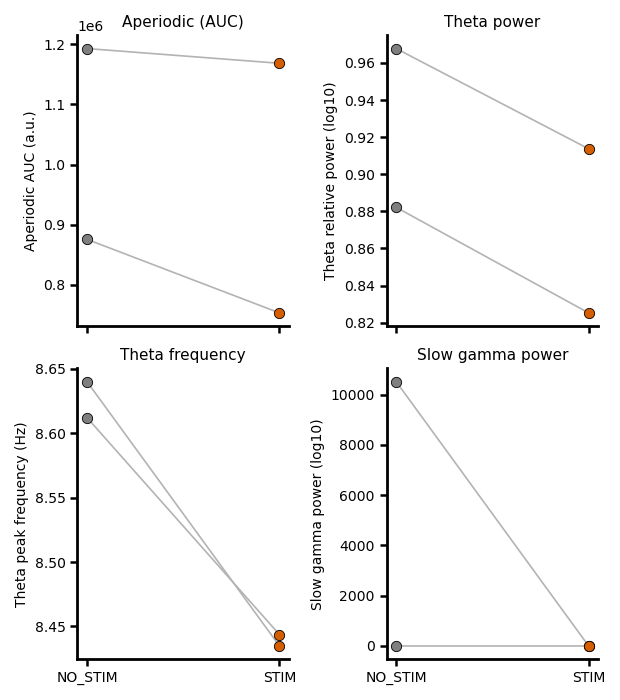

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(6.2, 7), sharex=True)

# 1) Aperiodic AUC (3–15 + 15–150 Hz)
paired_dotplot(
    axes[0, 0],
    aper_auc_off,
    aper_auc_on,
    ylabel="Aperiodic AUC (a.u.)",
    title="Aperiodic (AUC)"
)

# 2) Theta relative power (FOOOF peak height)
paired_dotplot(
    axes[0, 1],
    theta_pow_off,
    theta_pow_on,
    ylabel="Theta relative power (log10)",
    title="Theta power"
)

# 3) Theta peak frequency
paired_dotplot(
    axes[1, 0],
    theta_freq_off,
    theta_freq_on,
    ylabel="Theta peak frequency (Hz)",
    title="Theta frequency"
)

# 4) Slow gamma power (FOOOF peak height)
paired_dotplot(
    axes[1, 1],
    gamma_pow_off,
    gamma_pow_on,
    ylabel="Slow gamma power (log10)",
    title="Slow gamma power"
)

plt.tight_layout()
plt.show()

## Extracting SWRs and determining main properties 

First extraction of SWR peaks, initiation, end and width

In [ ]:
# 3 sd threshold
peaks, properties = find_peaks(proj_CA1W0Lcwt, prominence=1, width=20, height=sd3proj_CA1cwt)
properties["prominences"], properties["widths"]

# SWR boundaries taken at 70% from peak of intensity. This means that the SWRs with small amplitude will be longer than the big ones.
results_width = peak_widths(proj_CA1W0Lcwt, peaks, rel_height=0.7)

# Organise results in numpy array
peaks2 = peaks.reshape(len(peaks),1)
npresults_width = np.array(results_width).reshape(4,-1)
SWR_prop = np.append(peaks2, results_width).reshape(5,len(peaks2)).round()

Display subset

Second extraction of main frequency and power 

In [ ]:
projMaxP_cwtmg = np.max(CA1cwtWake0lib, axis = 0)
projMaxF_cwtmg = np.argmax(CA1cwtWake0lib, axis = 0) + 120
projMaxP_cwtmg.shape

nb_SWR = len(peaks)
data = np.zeros((nb_SWR,4))

for tt in np.arange(nb_SWR):
    SWR_start = int(SWR_prop[3,tt])
    SWR_stop = int(SWR_prop[4,tt])
    SWR_MaxP = projMaxP_cwtmg[SWR_start:SWR_stop]
    SWR_MaxF = projMaxF_cwtmg[SWR_start:SWR_stop]
    data[tt, 0] = max(SWR_MaxF).round()
    data[tt, 1] = max(SWR_MaxP).round()
    data[tt, 2] = round(sum(SWR_MaxF)/len(SWR_MaxF))
    data[tt, 3] = round(sum(SWR_MaxP)/len(SWR_MaxP))

param_SWR = pd.DataFrame(data, columns = ['Max freq', 'Max int', 'Avg freq', 'Avg int'])
tSWR_prop = SWR_prop.transpose()
pd_prop_SWR = pd.DataFrame(tSWR_prop, columns = ['peak time', 'Duration', 'peak amp', 'start time', 'end time'])
pd_tokeep = pd.DataFrame(np.ones(nb_SWR).astype(bool), columns = ['toKeep'])
All_SWR = pd.concat([pd_tokeep,pd_prop_SWR, param_SWR], axis=1)

SWR_peak = peaks
SWR_start = SWR_prop[3,:].astype(int)
SWR_end = SWR_prop[4,:].astype(int)

### Store the results in All_SWR_prop pd dataframe and save as pkl/csv for post processing.

End of Notebook. 

In [ ]:
filename2 = os.path.join(dpath,f'SWRproperties{suffix}.pkl')
filename3 = os.path.join(dpath,f'SWRproperties{suffix}.csv')
All_SWR.to_pickle(filename2)
All_SWR.to_csv(filename3, sep = ',')

combined = np.stack([CA1, filt_CA1, proj_CA1W0Ccwt, proj_CA1W0Lcwt], axis = 1)
filenameC = os.path.join(dpath,f'SignalCA1.npy')
np.save(filenameC, combined)

sample_rate = 1000.
t_start = 0.
# if done and no intention to display for assessment
#%reset
#plt.close('all')

### Display and asses SWRs

#### ephys viewer to check SWR detection

In [ ]:
%%capture
%gui qt

app = mkQApp()

#Create one data source with 3 event channel
all_events = []
conditions = ['All','Good','Bad']
for c,cond in enumerate(conditions):
    match cond:
        case 'All':
            selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
        case 'Good':
            selection = "All_SWR['toKeep']"
        case 'Bad':
            selection = "~All_SWR['toKeep']"
    ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
    ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
    all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
source_ev = InMemoryEventSource(all_events=all_events)

combined = np.stack([CA1, fCA1wake0C, proj_CA1W0Lcwt, proj_CA1W0Ccwt, TTL], axis = 1)

sample_rate = 1000.
t_start = 0.

#create 2 familly scatters from theses 2 indexes
scatter_indexes = {0: SWR_peak, 1: SWR_start, 2: SWR_end}
#and asign them to some channels each
scatter_channels = {0: [1, 2], 1: [0, 1], 2: [0, 1]}
source = AnalogSignalSourceWithScatter(combined, sample_rate, t_start, scatter_indexes, scatter_channels)

#Create the main window that can contain several viewers
win = MainViewer(debug=True, show_auto_scale=True)

#create a viewer for signal with TraceViewer
#connected to the signal source
view1 = TraceViewer(source=source)

#Parameters can be set in script
view1.params['scale_mode'] = 'same_for_all'
view1.params['display_labels'] = True
view1.auto_scale()

nCh = len(view1.by_channel_params.children())
mult = 5
for ch in range(nCh):
    match ch%mult:
        case 0: # raw traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 2.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.05
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 1: # filtered traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#0055ff'
        case 2: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ff5500'
        case 3: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 4: # TTL
            view1.by_channel_params[f'ch{ch}', 'offset'] = 4.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
view1.params['ylim_max']=5*int((nCh+1)/mult)
view1.params['ylim_min']=0

view2 = EventList(source=source_ev, name='event')


#put this viewer in the main window
win.add_view(view1)
win.add_view(view2, location='bottom',  orientation='horizontal')

#Run
win.show()

#### Select and deselect SWRs

In [ ]:
def clicked(arg):
    selectedEvent = view2.list_widget.currentItem().text()
    selectedSWR = int(selectedEvent.split('SWR')[1])
    #print(selectedSWR)
    match arg.description:
        case 'Keep SWR':
            All_SWR.loc[selectedSWR,'toKeep']=True
            print(f'SWR {selectedSWR} restored')
        case 'Discard SWR':
            All_SWR.loc[selectedSWR,'toKeep']=False
            print(f'SWR {selectedSWR} discarded')
    #save modif
    All_SWR.to_pickle(filename2)
    All_SWR.to_csv(filename3, sep = ',')
    #Create one data source with 3 event channel
    all_events = []
    conditions = ['All','Good','Bad']
    for c,cond in enumerate(conditions):
        match cond:
            case 'All':
                selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
            case 'Good':
                selection = "All_SWR['toKeep']"
            case 'Bad':
                selection = "~All_SWR['toKeep']"
        ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
        ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
        all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
    source_ev = InMemoryEventSource(all_events=all_events)
    view2.source = source_ev
    view2.refresh_list(view2.combo.currentIndex())

button_Good = widgets.Button(description = 'Keep SWR')   
button_Good.on_click(clicked)

button_Bad = widgets.Button(description = 'Discard SWR')   
button_Bad.on_click(clicked)

display(button_Good, button_Bad)



In [ ]:
# plotting the points
plt.scatter(np.zeros(len(MaxSWR)), MaxSWR)
plt.scatter(np.ones(len(AvgSWR)), AvgSWR)


In [ ]:
# plotting the lines
for i in range(len(MaxSWR)):
    plt.plot( [0,1], [MaxSWR[i], AvgSWR[i]], c='k')


In [ ]:
# ============================================================
# Sanity plot: LFP + shaded trains + TTL trace overlay
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def sanity_plot_trains_on_trace(
    lfp_ds, fs, trains_ds,
    ch=0,
    start_s=0.0, window_s=10.0,
    y_mode="percentile",   # "percentile" or "fixed"
    y_fixed=2000.0,
    train_alpha=0.18,
    ttl_trace=None,          # 1D array in DS samples (same length as lfp_ds)
    ttl_pulses_ds=None,      # optional Nx2 [start,end] to synthesize TTL trace
    ttl_height=0.15,         # fraction of axis height used for TTL display
    ttl_color="k"
):
    """
    Plot ONE channel trace with STIM-ON trains shaded.
      lfp_ds: (time, ch)
      trains_ds: Nx2 int [start_idx, end_idx] in DS sample indices
      ttl_trace: optional 1D array to overlay (e.g., raw TTL channel)
      ttl_pulses_ds: optional pulses to build a binary TTL trace
    """
    x = np.asarray(lfp_ds[:, ch], dtype=np.float32)
    n = x.size
    trains_ds = np.asarray(trains_ds, dtype=np.int64) if trains_ds is not None else np.zeros((0, 2), dtype=np.int64)

    # build TTL trace if needed
    if ttl_trace is None and ttl_pulses_ds is not None:
        ttl_trace = np.zeros(n, dtype=np.float32)
        for s_idx, e_idx in np.asarray(ttl_pulses_ds, dtype=np.int64):
            s0 = max(0, int(s_idx))
            e0 = min(n, int(e_idx))
            if e0 > s0:
                ttl_trace[s0:e0] = 1.0

    fig, ax = plt.subplots(figsize=(10, 4))
    plt.subplots_adjust(bottom=0.18)

    ax_sl = fig.add_axes([0.12, 0.05, 0.76, 0.05])
    max_start = max(0.0, (n / fs) - window_s)
    fig._slider = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)
    sld = fig._slider

    def set_ylim(seg):
        if y_mode == "fixed":
            ax.set_ylim(-y_fixed, y_fixed)
        else:
            lo, hi = np.percentile(seg, [1, 99])
            pad = 0.25 * (hi - lo + 1e-9)
            ax.set_ylim(lo - pad, hi + pad)

    def render(s0):
        ax.clear()
        i0 = int(s0 * fs)
        i1 = min(int((s0 + window_s) * fs), n)

        t = np.arange(i0, i1) / fs
        seg = x[i0:i1]

        ax.plot(t, seg, lw=0.8, label=f"ch{ch}")

        # shade trains that overlap this window
        if trains_ds.size:
            mask = (trains_ds[:, 1] > i0) & (trains_ds[:, 0] < i1)
            first = True
            for s_idx, e_idx in trains_ds[mask]:
                s = max(int(s_idx), i0) / fs
                e = min(int(e_idx), i1) / fs
                ax.axvspan(s, e, alpha=train_alpha, label="STIM train" if first else None)
                first = False

        ax.set_xlim(s0, s0 + window_s)
        set_ylim(seg)

        # overlay TTL trace near the top of the axis
        if ttl_trace is not None:
            ttl_seg = np.asarray(ttl_trace[i0:i1], dtype=np.float32)
            y0, y1 = ax.get_ylim()
            h = (y1 - y0) * float(ttl_height)
            base = y1 - h
            y = base + ttl_seg * h
            ax.plot(t, y, color=ttl_color, lw=1.0, label="TTL")

        ax.set_xlabel("Time (s)")
        ax.set_ylabel(f"ch{ch} (a.u.)")
        ax.set_title(f"Sanity check: channel {ch} with STIM trains + TTL | fs={fs:.0f} Hz")
        ax.grid(False)

        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc="upper right")

        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()

# ---- Run it ----
# Option A: if you already have a TTL trace array (same length as lfp_ds), pass it as ttl_trace.
# Option B: build TTL from pulses_ds via ttl_pulses_ds.
sanity_plot_trains_on_trace(
    lfp_ds=lfp_ds,
    fs=fs_ds,
    trains_ds=stim_trains_ds,
    ch=15,
    start_s=0.0,
    window_s=10.0,
    y_mode="percentile",
    ttl_pulses_ds=pulses_ds,   # or ttl_trace=TTL
)
